In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене
print(len(model.feature_names_))

121


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()

blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08


count       345.000000
mean     135312.357566
std       73381.090181
min        1956.969214
25%       65113.869242
50%      151276.294259
75%      201065.711103
max      259942.812034
Name: price_per_sotka, dtype: float64


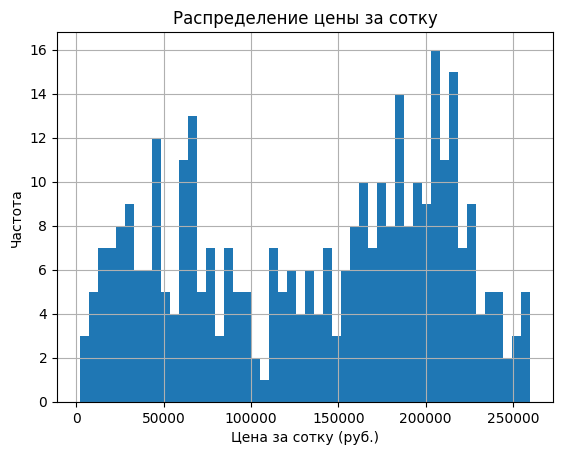

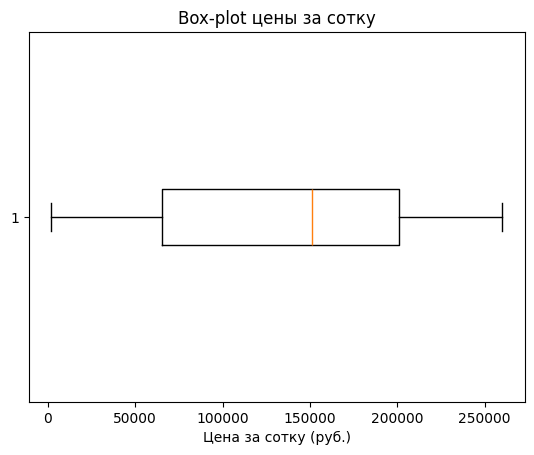

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


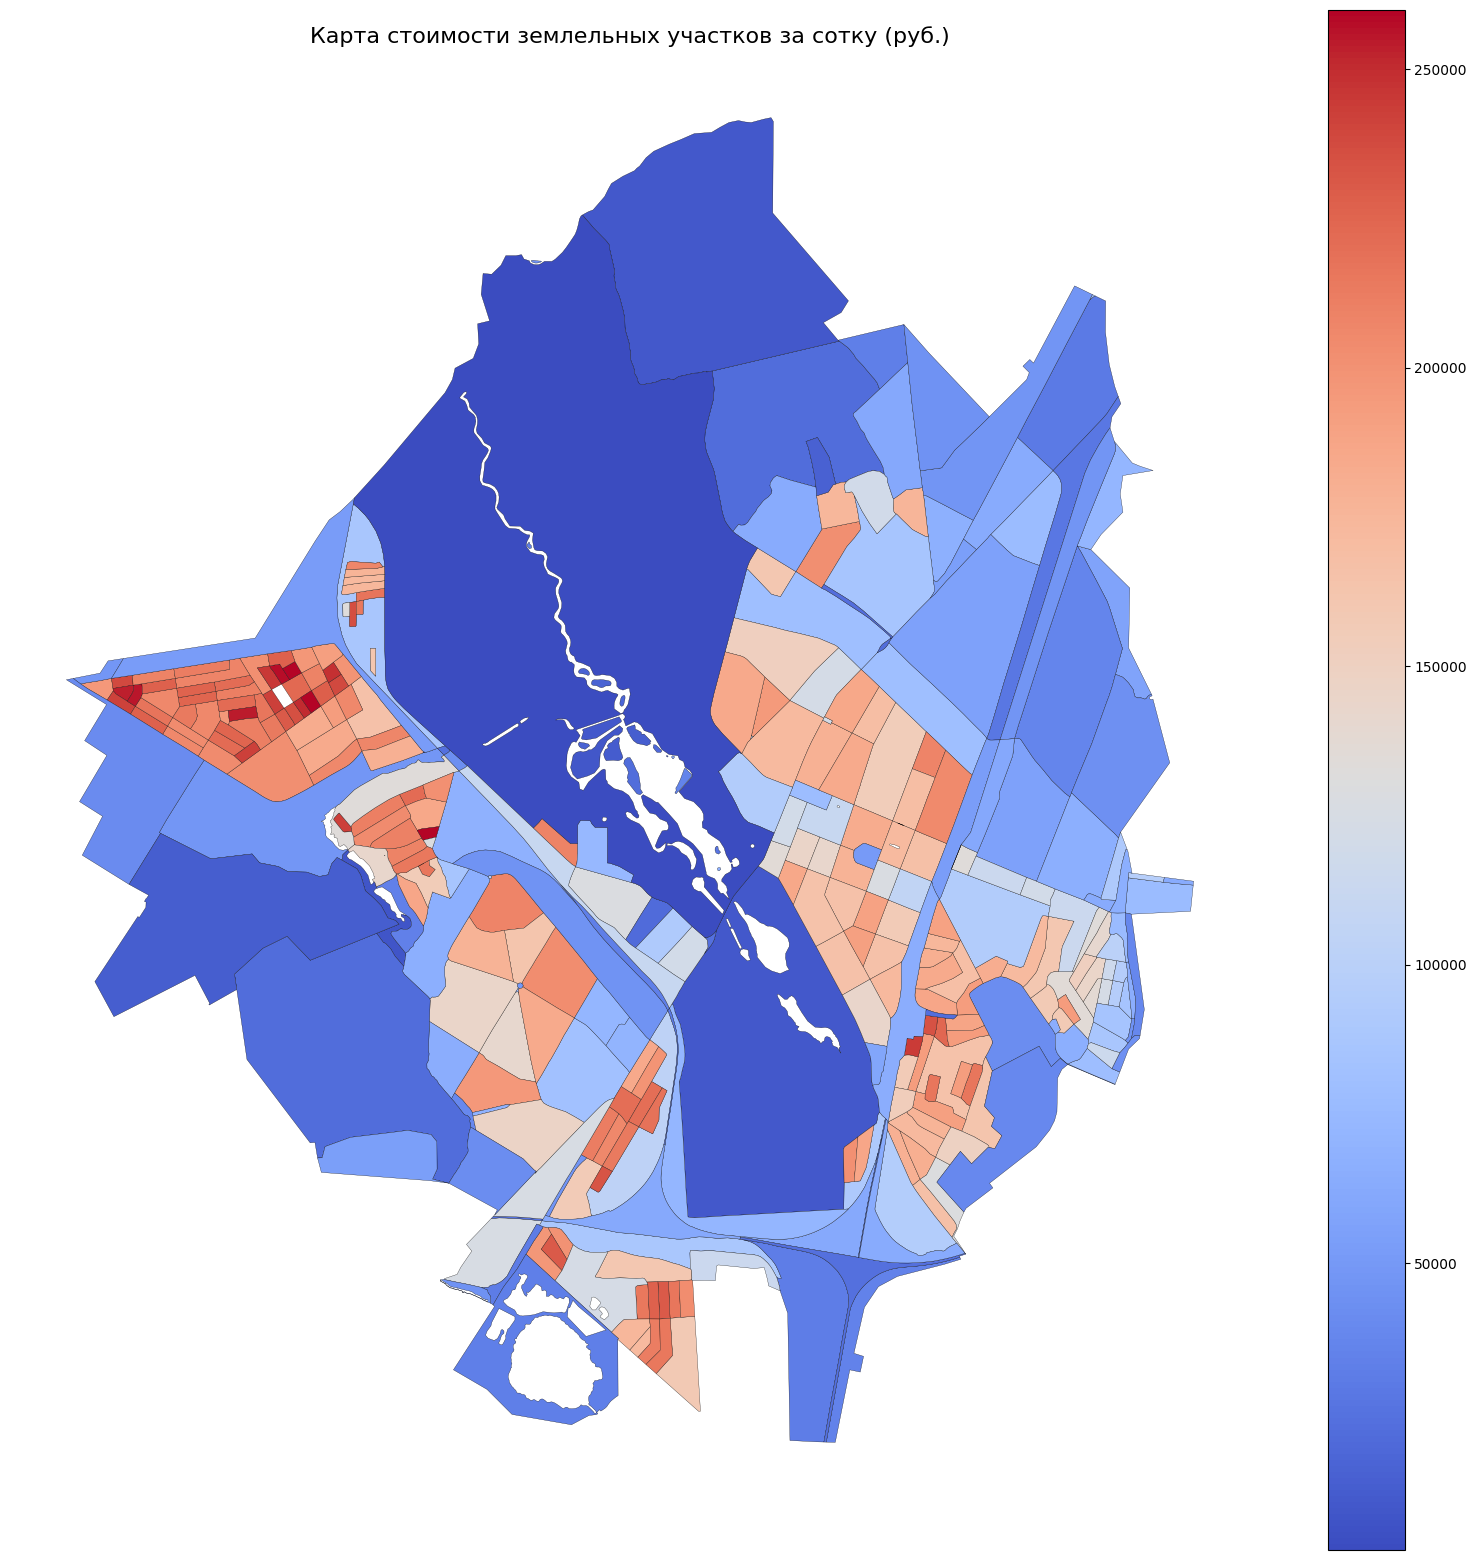

In [8]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

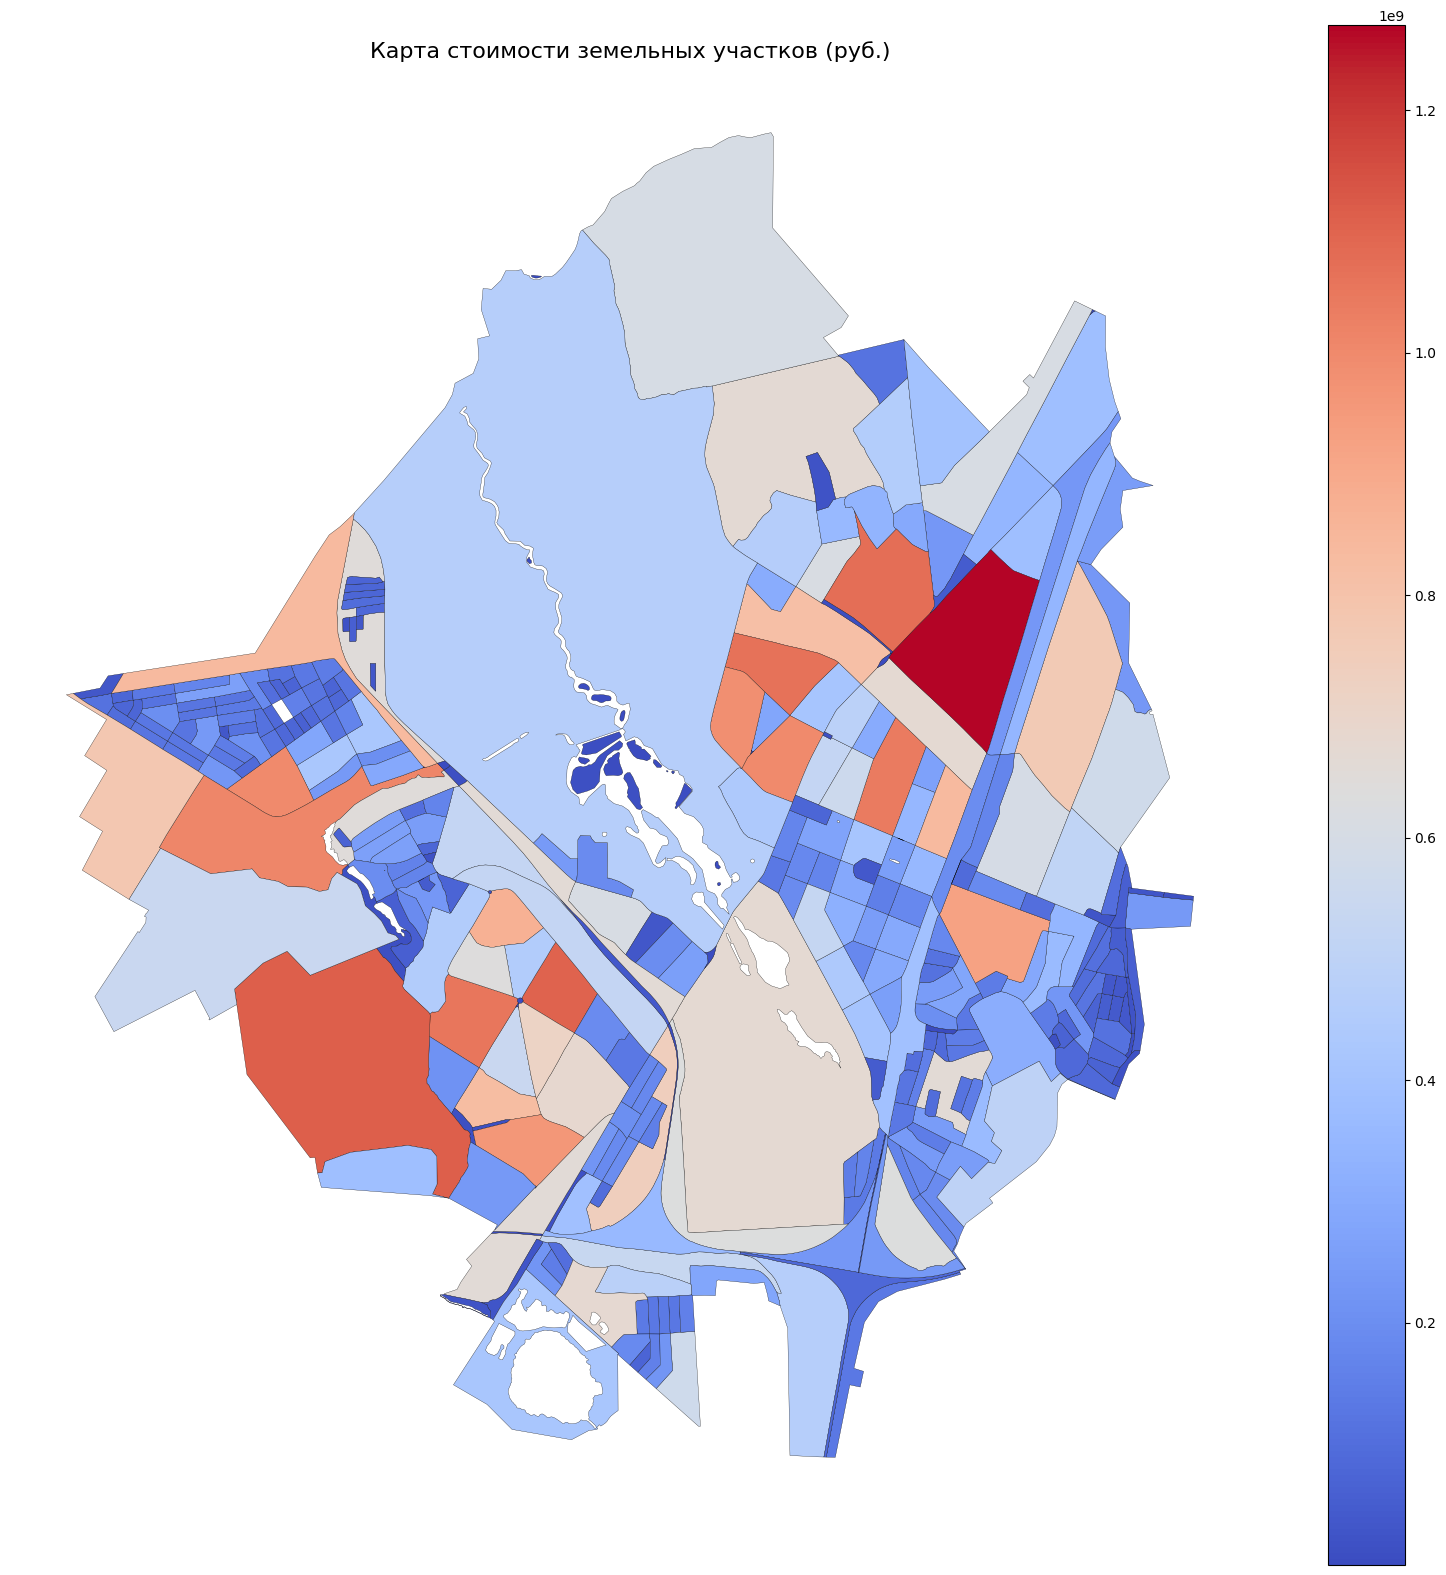

In [9]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [10]:
blocks_clean["id"] = blocks_clean.index

In [11]:
# blocks_clean.explore()

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_6787/1807181840.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(


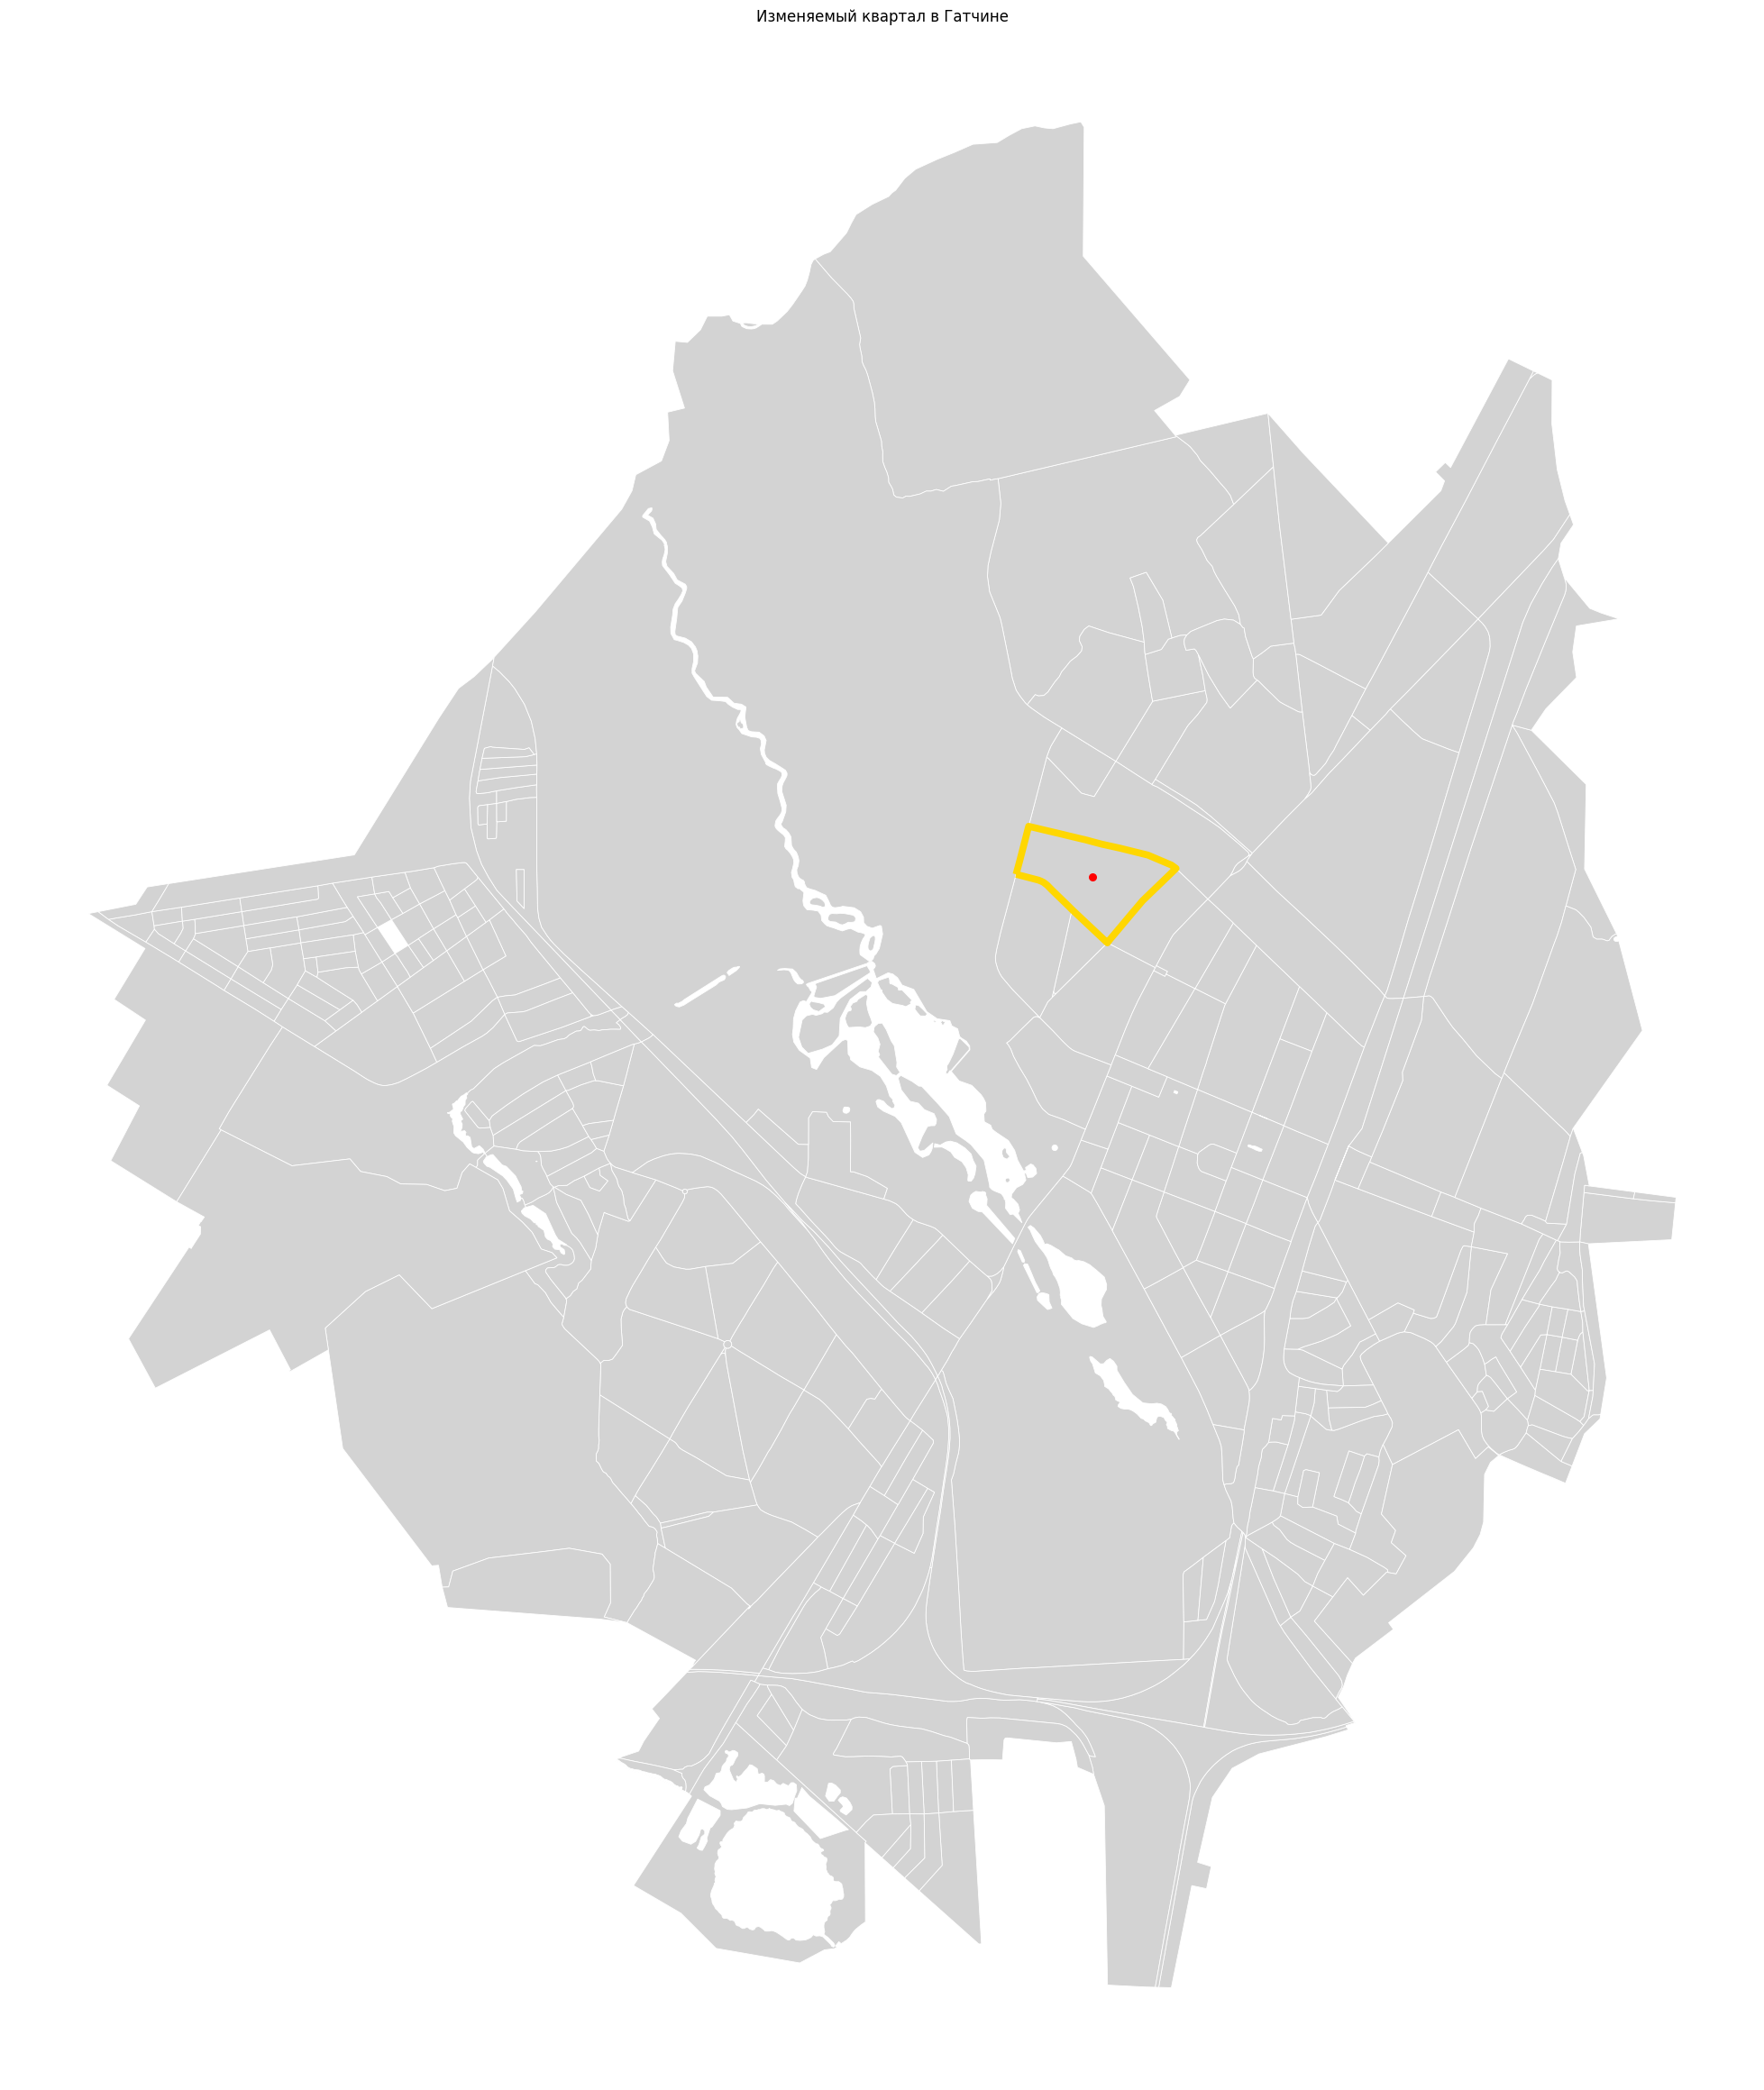

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==87].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

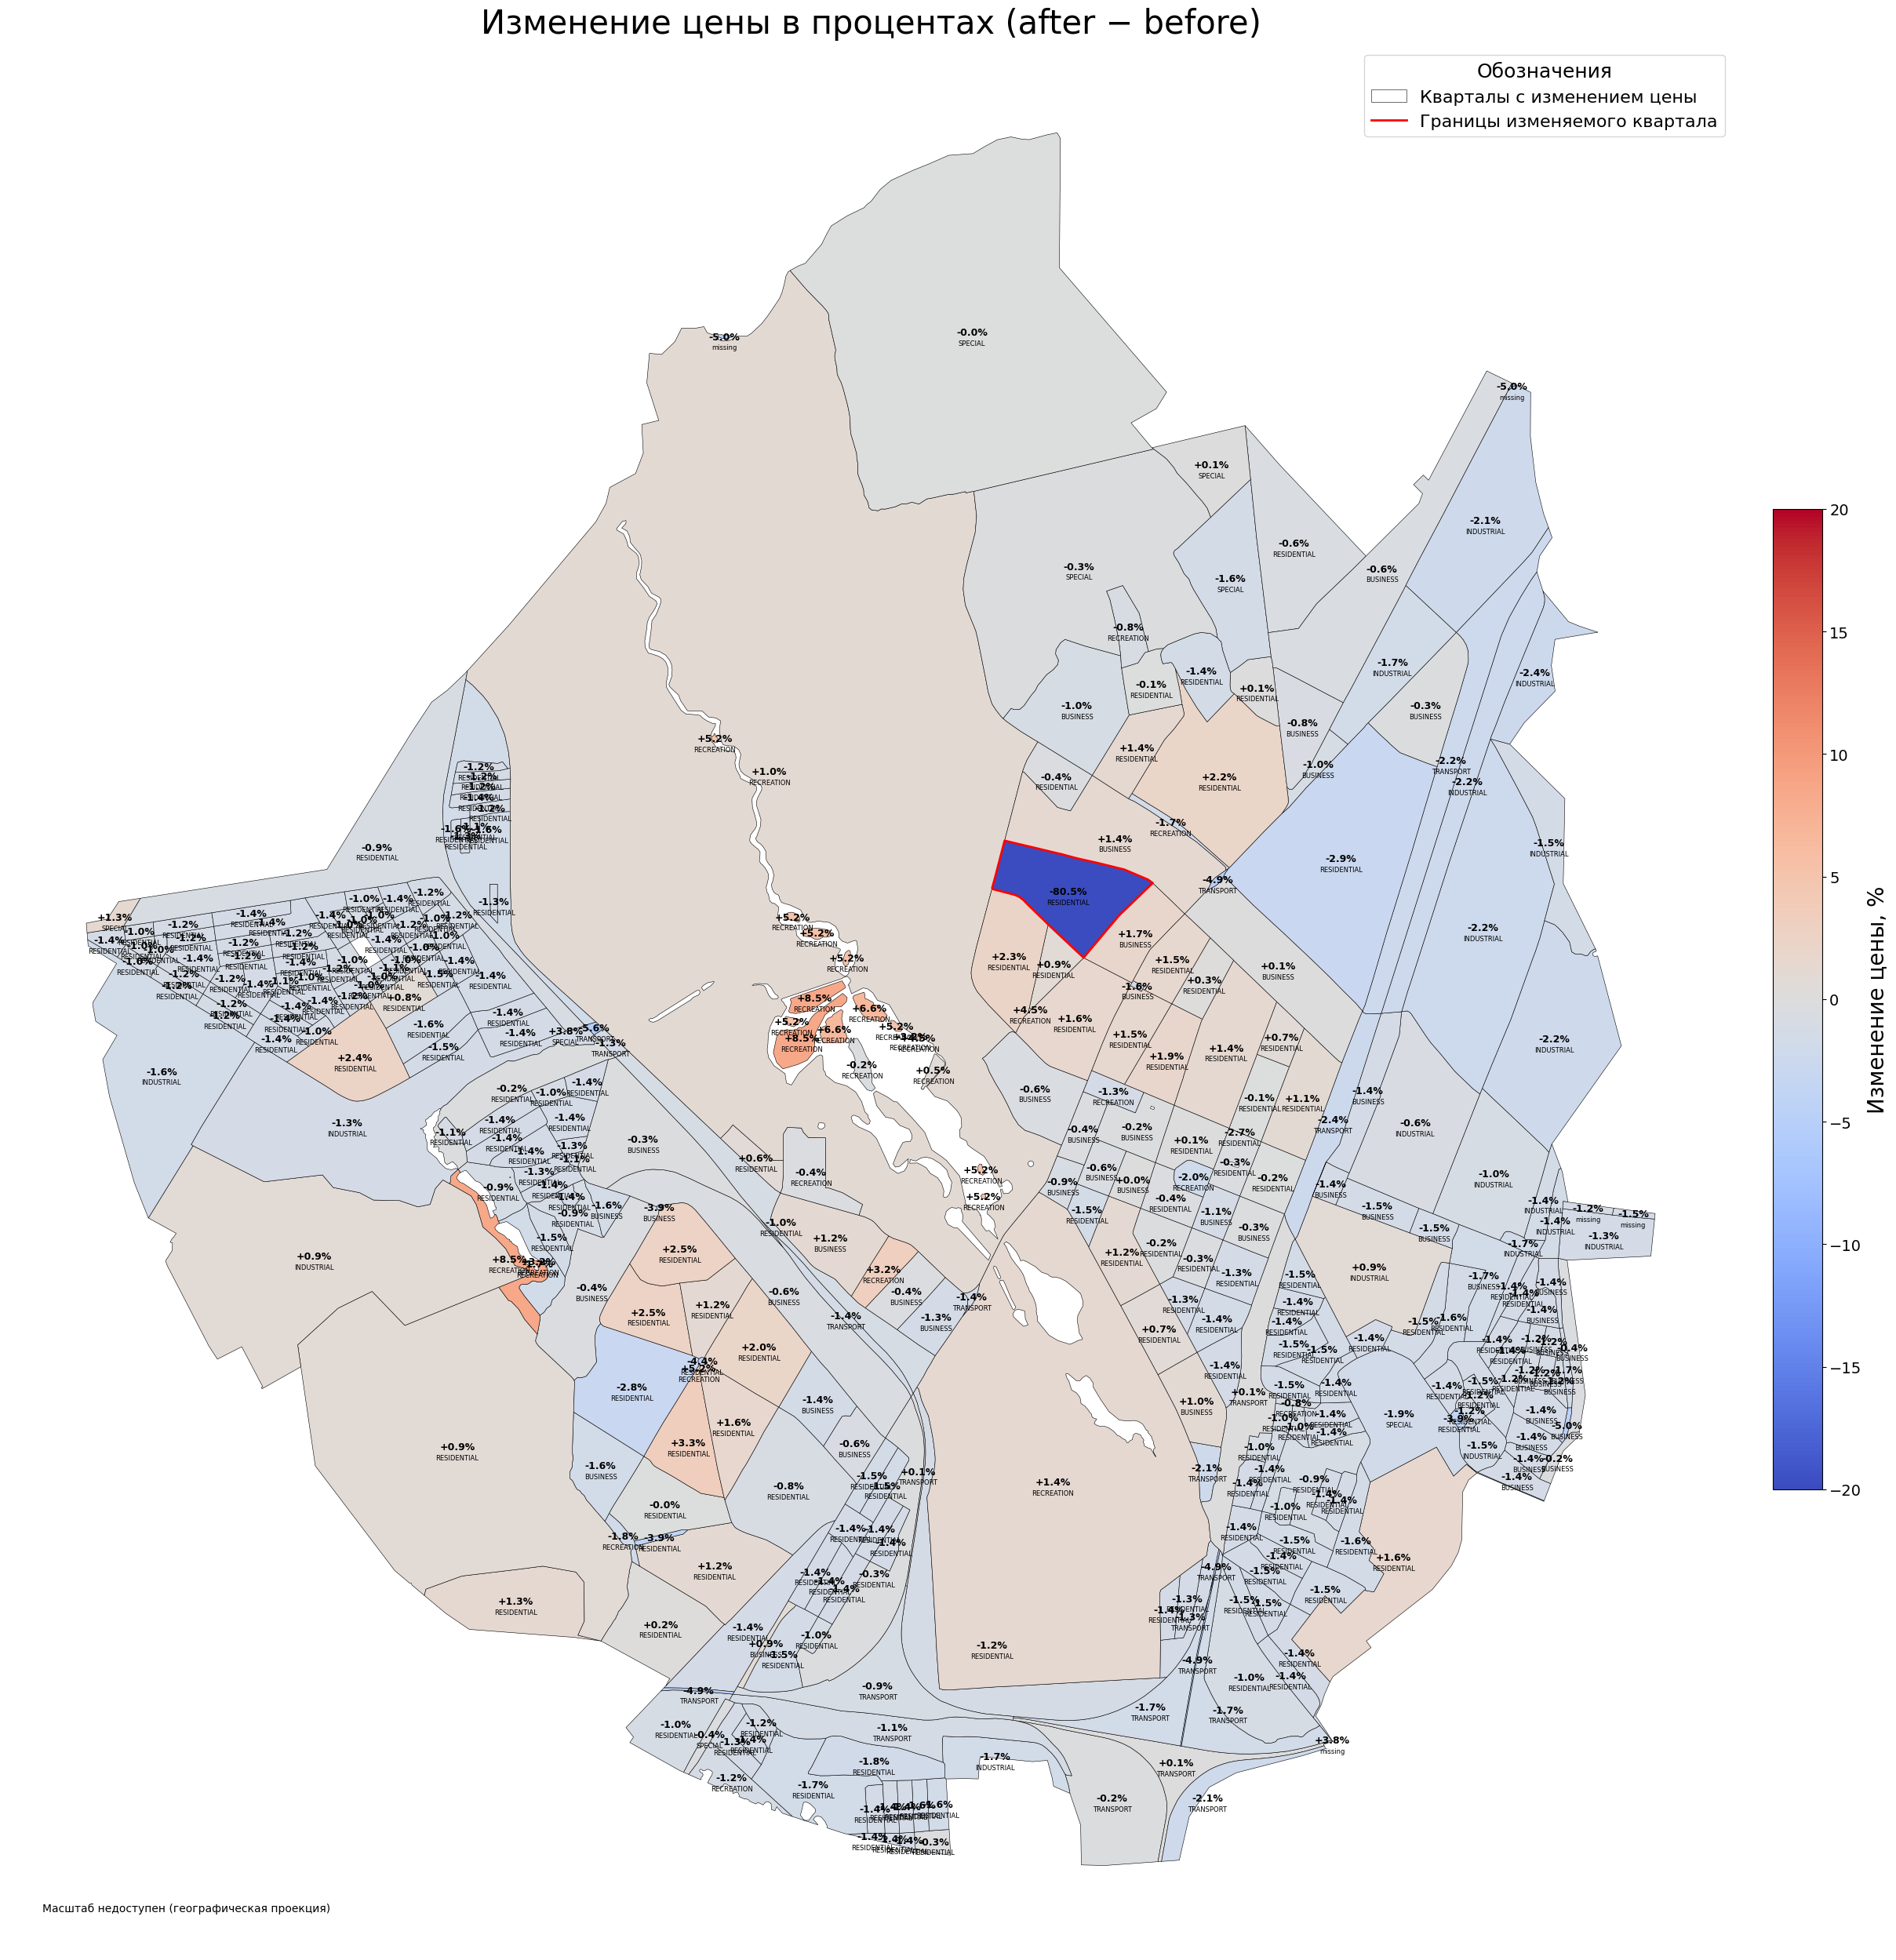


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | RESIDENTIAL | 1 044 985 582 ₽ → 204 203 057 ₽ | -840 782 525 ₽ | -80.5%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 558 068 634 ₽ → 556 360 738 ₽ | -1 707 896 ₽ | -0.3%
248 | TRANSPORT | 463 610 653 ₽ → 462 661 846 ₽ | -948 807 ₽ | -0.2%
298 | TRANSPORT | 90 038 010 ₽ → 90 119 286 ₽ | +81 276 ₽ | +0.1%
115 | RESIDENTIAL | 129 175 469 ₽ → 127 108 601 ₽ | -2 066 868 ₽ | -1.6%
317 | RESIDENTIAL | 157 610 237 ₽ → 155 124 501 ₽ | -2 485 735 ₽ | -1.6%
318 | INDUSTRIAL | 283 475 839 ₽ → 278 647 666 ₽ | -4 828 173 ₽ | -1.7%
225 | TRANSPORT | 237 712 832 ₽ → 233 759 373 ₽ | -3 953 459 ₽ | -1.7%
299 | TRANSPORT | 3 887 664 ₽ → 3 698 518 ₽ | -189 146 ₽ | -4.9%
5 | TRANSPORT | 134 459 896 ₽ → 132 667 343 ₽ | -1 792 553 ₽ | -1.3%
113 | RESIDENTIAL | 

In [13]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)
# Все снесли - ничего не осталось
blocks_after = blocks_clean
changes = {
        # Структура использования территории
        "residential": 0.0,
        "business": 0.0,
        "recreation": 0.0,
        "industrial": 0.0,
        "transport": 0.0,
        "special": 0.0,
        "agriculture": 0.0,
        "share": 1.0,

    
    "footprint_area": 0.0,   
    "build_floor_area": 0.0,  
    "living_area": 0.0,      
    "non_living_area": 0.0,  
    "population": 0.0,                

    
    "fsi": 0.0,                         
    "gsi": 0.0,                        
    "l": 0.0,                          
                     

        
        "morphotype": "low-rise non-residential",
}

target_idx = 87

modifier = ScenarioTEPModifier(blocks_after)
blocks_before = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_after,
    blocks_after=blocks_before,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

In [14]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

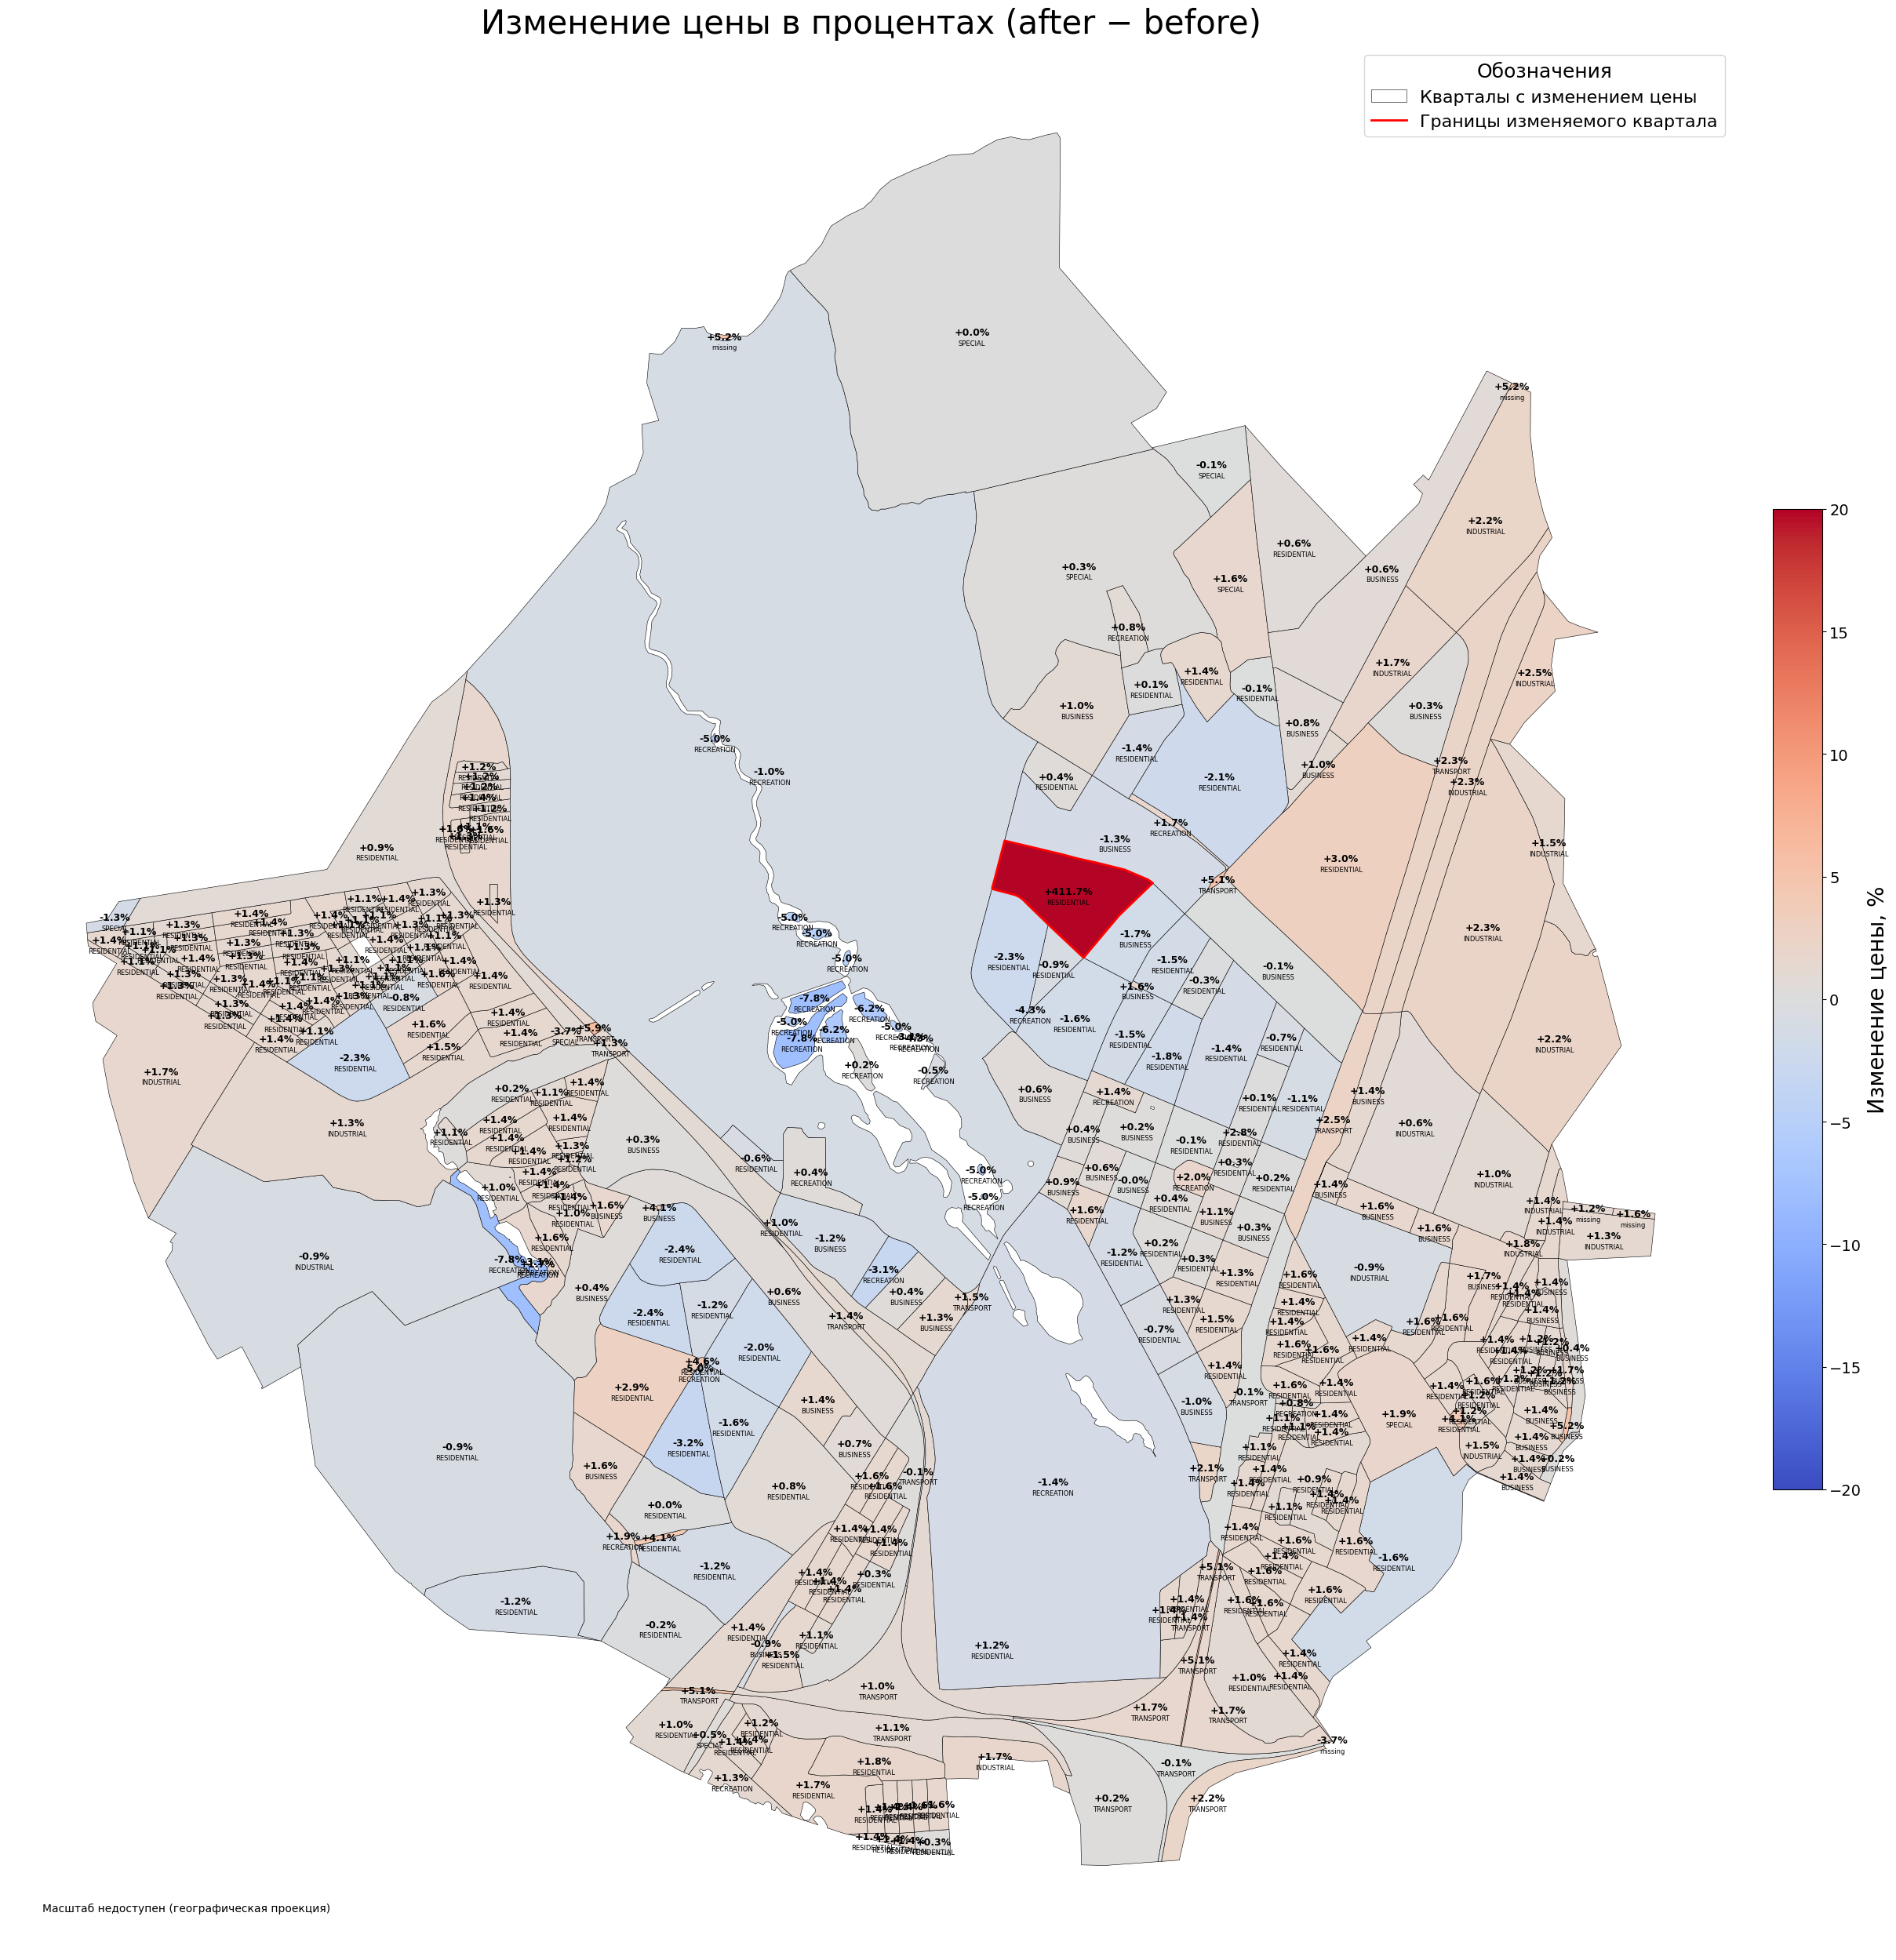


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | RESIDENTIAL | 204 203 057 ₽ → 1 044 985 582 ₽ | +840 782 525 ₽ | +411.7%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 556 360 738 ₽ → 558 068 634 ₽ | +1 707 896 ₽ | +0.3%
248 | TRANSPORT | 462 661 846 ₽ → 463 610 653 ₽ | +948 807 ₽ | +0.2%
298 | TRANSPORT | 90 119 286 ₽ → 90 038 010 ₽ | -81 276 ₽ | -0.1%
115 | RESIDENTIAL | 127 108 601 ₽ → 129 175 469 ₽ | +2 066 868 ₽ | +1.6%
317 | RESIDENTIAL | 155 124 501 ₽ → 157 610 237 ₽ | +2 485 735 ₽ | +1.6%
318 | INDUSTRIAL | 278 647 666 ₽ → 283 475 839 ₽ | +4 828 173 ₽ | +1.7%
225 | TRANSPORT | 233 759 373 ₽ → 237 712 832 ₽ | +3 953 459 ₽ | +1.7%
299 | TRANSPORT | 3 698 518 ₽ → 3 887 664 ₽ | +189 146 ₽ | +5.1%
5 | TRANSPORT | 132 667 343 ₽ → 134 459 896 ₽ | +1 792 553 ₽ | +1.4%
113 | RESIDENTIAL |

In [15]:
# Теперь все вернули обратно!
scenario_result = plot_scenario_impact(
    blocks_before=blocks_before, # поменял местами датафреймы!
    blocks_after=blocks_after,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

# Оптимизация агентами!

# **Инвестиционная** привлекактельтность 

In [16]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [17]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


In [18]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/gatchina/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2026-02-18 14:05:52.733 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential,land_use_before
0,LandUse.RESIDENTIAL,1.066619e+09,1.066619e+09,705080.041579,132192.815395,58395.681287,190588.496682,0.690324,0.0,


In [19]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          705,080.04
 • Built area:         190,588.50
 • Land value:         1,066,618,958.46
 • Demolition cost:    171,529,647.01
 • Construction cost:  8,576,482,350.68
 • Investment need:    9,814,630,956.15
 • Spatial potential:  0.00
 • Project NPV:        4,191,416,222.15
 • Project IRR:        0.33
 • Project ROI:        5.19
 • Project PP (yrs):   5.38
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,190588.5,1.066619e+09,1.715296e+08,8.576482e+09,9.814631e+09,4.191416e+09,0.33,5.19,5.38,100.0,0.0,60.0


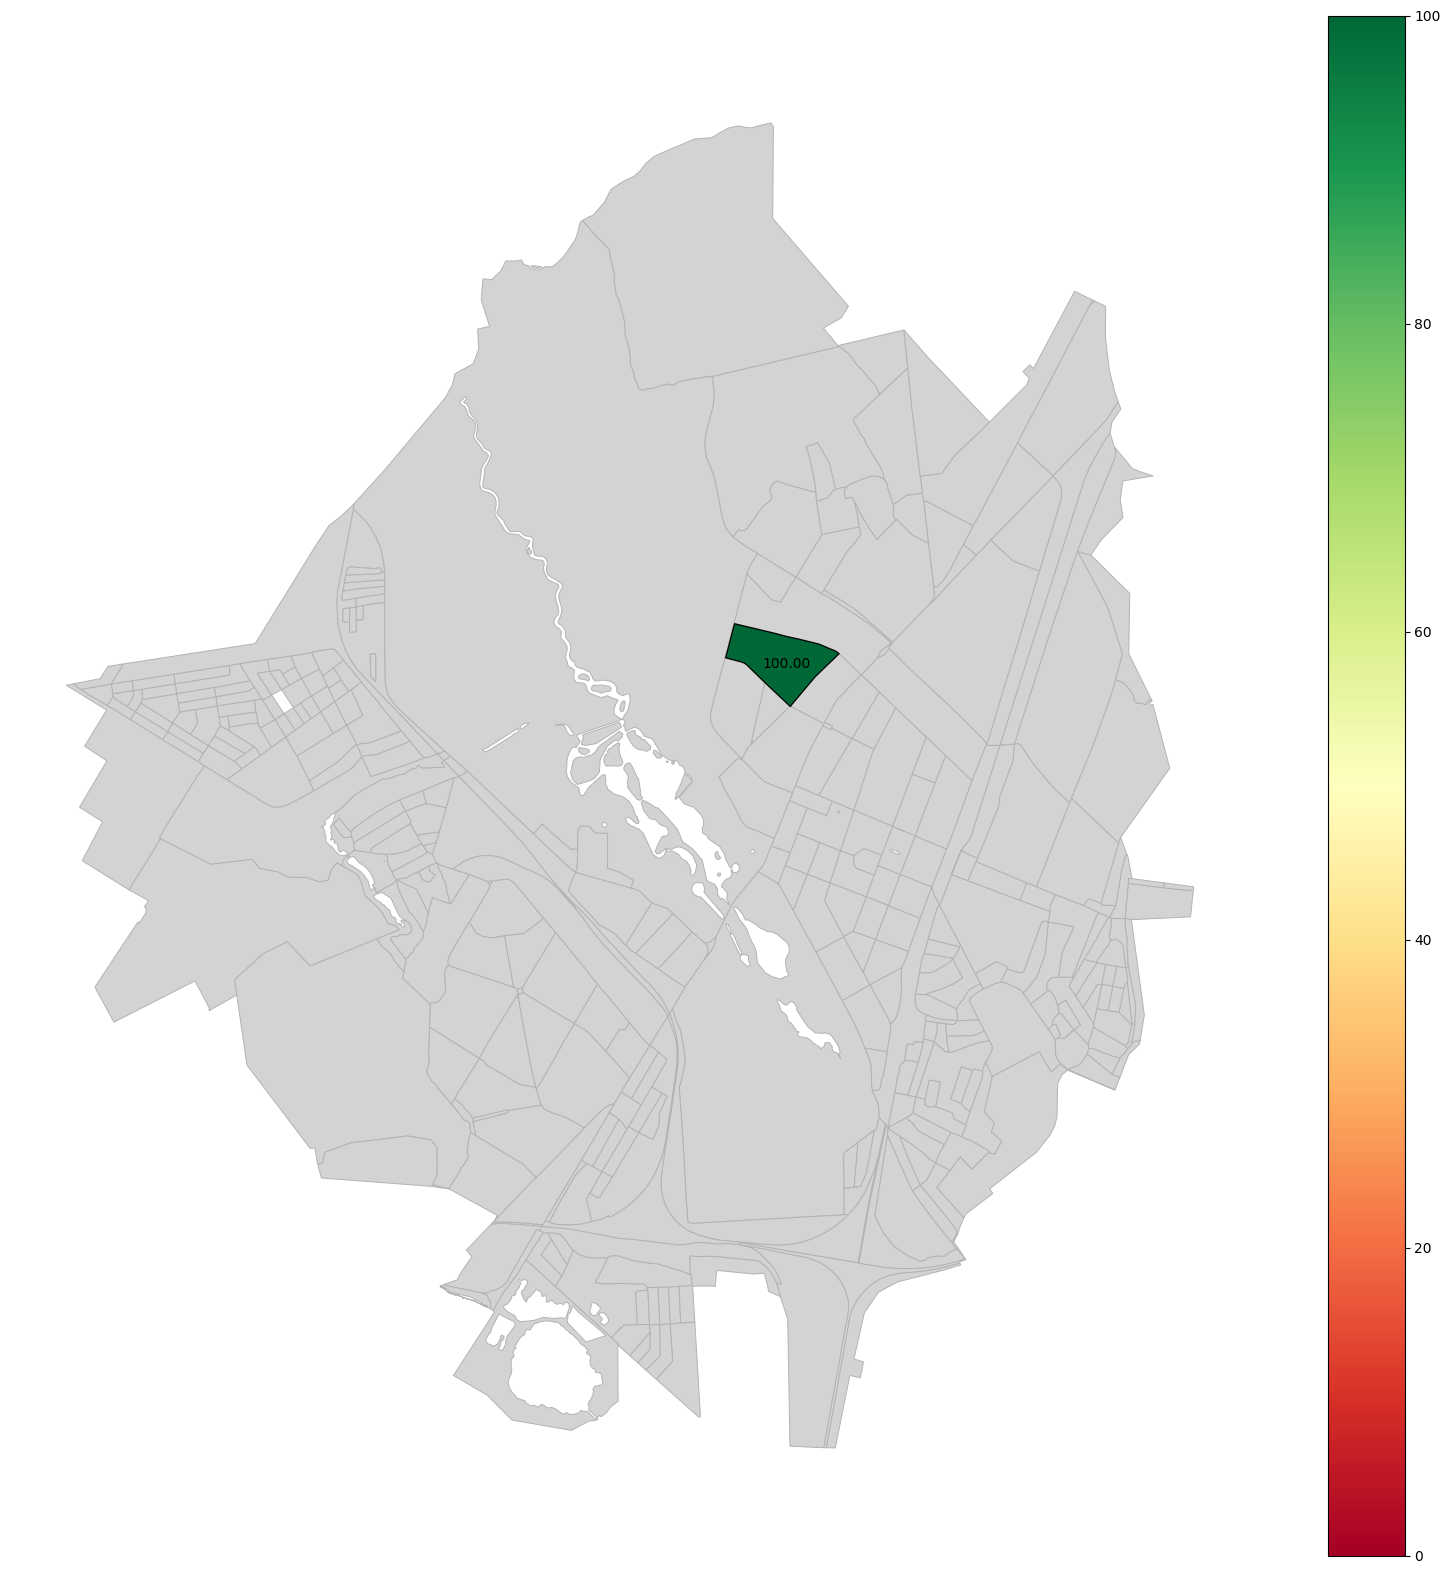

In [20]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [21]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,28 588
1,Валовый региональный продукт на душу населения,14 135
2,Доходы бюджета территории,514 588 941
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),244 430


## Оптимизация пустого района

In [22]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 87
blocks_after.iloc[86]
site_area = float(blocks_after["site_area"].iloc[86])
floors_neighborhood_avg = blocks_after['build_floor_area'].mean() 


In [46]:
problem = DistrictProblem(
    blocks=blocks_after,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    potential_df=potential_df,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.09 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 15.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},



    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [47]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 20),
    seed=42,
    verbose=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      5 |             - |             -
     2 |       40 |      5 |  0.0092997174 |         ideal
     3 |       60 |      6 |  0.0495026202 |         ideal
     4 |       80 |      9 |  0.1011522907 |         ideal
     5 |      100 |      7 |  0.0698690084 |         ideal
     6 |      120 |     10 |  0.4450046587 |         ideal
     7 |      140 |      9 |  0.0488358855 |             f
     8 |      160 |     10 |  0.1591261561 |         ideal
     9 |      180 |     10 |  0.0688816453 |         ideal
    10 |      200 |      7 |  0.1038996713 |         nadir
    11 |      220 |     11 |  0.0210902095 |         ideal
    12 |      240 |     13 |  0.1251223986 |         ideal
    13 |      260 |     10 |  0.1731937277 |         ideal
    14 |      280 |     15 |  0.0047532977 |         ideal
    15 |      300 |     16 |  0.0134330817 |         ideal
    16 |      320 |     20 |  0.0219044058 |         nad

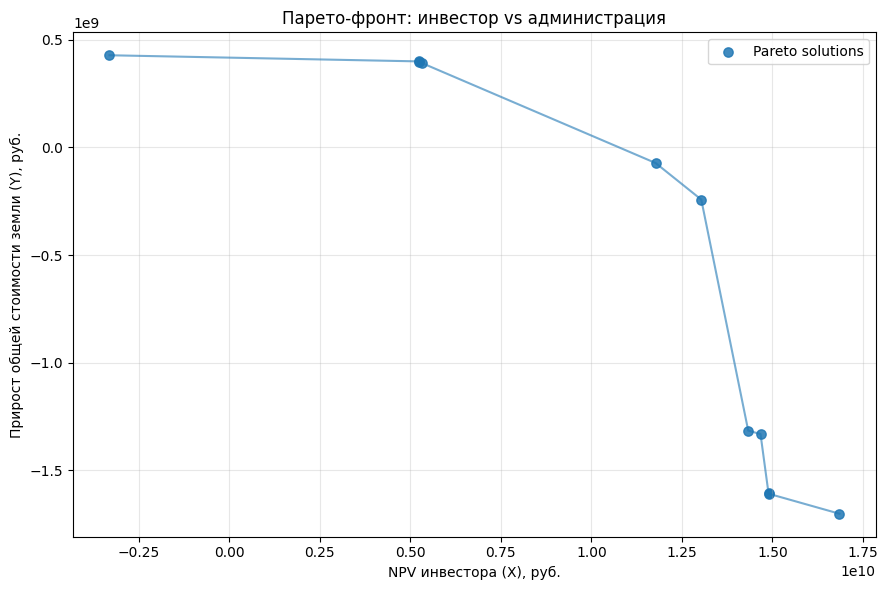

In [48]:
import numpy as np
import matplotlib.pyplot as plt


optimizer = problem

# 1) Базовая стоимость земли "до" (для расчета прироста)
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,  # возьмет дефолтные RADIUS_LIST внутри evaluate_catboost
)

# 2) Извлекаем цели из Pareto-решений
# В _evaluate у вас:
# F[:,0] = -land_value
# F[:,1] = -investment_potential (NPV)
F = res.F

land_value_total = -F[:, 0]                 # общая стоимость земли после сценария
admin_gain = land_value_total - baseline_land_value   # прирост для администрации (Y)
investor_npv = -F[:, 1]                     # NPV для инвестора (X)

# 3) Сортировка по X для красивой линии фронта
order = np.argsort(investor_npv)
x = investor_npv[order]
y = admin_gain[order]

# 4) График Парето-фронта
plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=45, alpha=0.85, label="Pareto solutions")
plt.plot(x, y, alpha=0.6)

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето-фронт: инвестор vs администрация")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[6.06053596e+04 9.55511550e+00 3.27021205e-01 8.10178614e-01
  2.17854494e-01 7.05928954e-02 4.99186570e-01 7.60559135e-01
  3.40805449e-01 3.01465950e-02]
 [6.05432815e+04 9.55511550e+00 3.27021205e-01 8.10178614e-01
  2.17854494e-01 7.05928954e-02 4.99186570e-01 7.60559135e-01
  3.40805449e-01 3.01465950e-02]
 [4.99711360e+04 1.02297769e+01 3.49176531e-01 9.06172294e-01
  2.81688960e-01 2.92750819e-01 6.07004720e-01 8.50506263e-01
  2.18059646e-01 5.60479285e-05]
 [5.02205311e+04 4.55679330e+00 3.49176531e-01 9.07363408e-01
  2.82197838e-01 2.88938866e-01 4.39782425e-01 8.50506263e-01
  3.64860859e-01 5.60479285e-05]
 [6.20008689e+04 9.20128434e+00 3.21071350e-01 8.08673243e-01
  2.14562965e-01 3.57892888e-02 5.00081885e-01 7.61679552e-01
  3.49801846e-01 4.32943852e-04]
 [6.20024388e+04 9.00225273e+00 3.21071350e-01 7.85214739e-01
  2.15150356e-01 3.56961332e-02 7.33712110e-01 7.60384227e-01
  3.49801846e-01 4.32943852e-04]
 [6.13569057e+04 1.05842363e

In [50]:
len(res.opt)

11

In [51]:
# for i, opt in enumerate(res.opt):
#     params = {name: opt.X[j] for j, name in enumerate(problem.var_names)}
#     params = problem._repair_genome(params)
#     plot_scenario_impact(
#         blocks_before=blocks_after,
#         blocks_after=ScenarioTEPModifier(blocks_after).apply(target_idx, params),
#         orig_features=numeric_feats+cat_features,
#         categorical_features=cat_features,
#         model=model,
#         target_idx=target_idx,
#         figsize=(25, 35),
#     )
#     print(f"Решение {i}:")
#     print("Переменные (геном):", opt.X)
#     print("Целевые функции:", -opt.F)
#     print("-" * 30)

In [62]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(50225.041652192434),
 'l': np.float64(4.709190020061533),
 'mxi': np.float64(0.3489548459126925),
 'residential': np.float64(0.775593591066767),
 'business': np.float64(0.25184944090211137),
 'recreation': np.float64(0.022180627921743523),
 'industrial': np.float64(0.7352555170881107),
 'transport': np.float64(0.8564146980811695),
 'special': np.float64(0.2208473630602632),
 'agriculture': np.float64(5.6047928471232664e-05)}

In [81]:
params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(50220.53105662728),
 'l': np.float64(4.556793298178112),
 'mxi': np.float64(0.3491765311534127),
 'residential': np.float64(0.9073634084977852),
 'business': np.float64(0.2821978375054209),
 'recreation': np.float64(0.28893886612806097),
 'industrial': np.float64(0.43978242485036084),
 'transport': np.float64(0.8505062634527198),
 'special': np.float64(0.364860858845869),
 'agriculture': np.float64(5.6047928471232664e-05)}

In [82]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 50220.53105662728,
 'l': 4.556793298178112,
 'mxi': 0.3491765311534127,
 'residential': 0.28954965567140273,
 'business': 0.09005243755221205,
 'recreation': 0.0922035740188985,
 'industrial': 0.14033941471871395,
 'transport': 0.27140591456825036,
 'special': 0.11643111795933912,
 'agriculture': 1.7885511183229998e-05,
 'share': 0.28954965567140273,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 228844.57934978494,
 'living_area': 79907.1563906198,
 'non_living_area': 148937.42295916512,
 'population': 3995.35781953099,
 'fsi': 0.3245653909552038,
 'gsi': 0.07122670916079755,
 'morphotype': 'mid-rise microdistrict'}

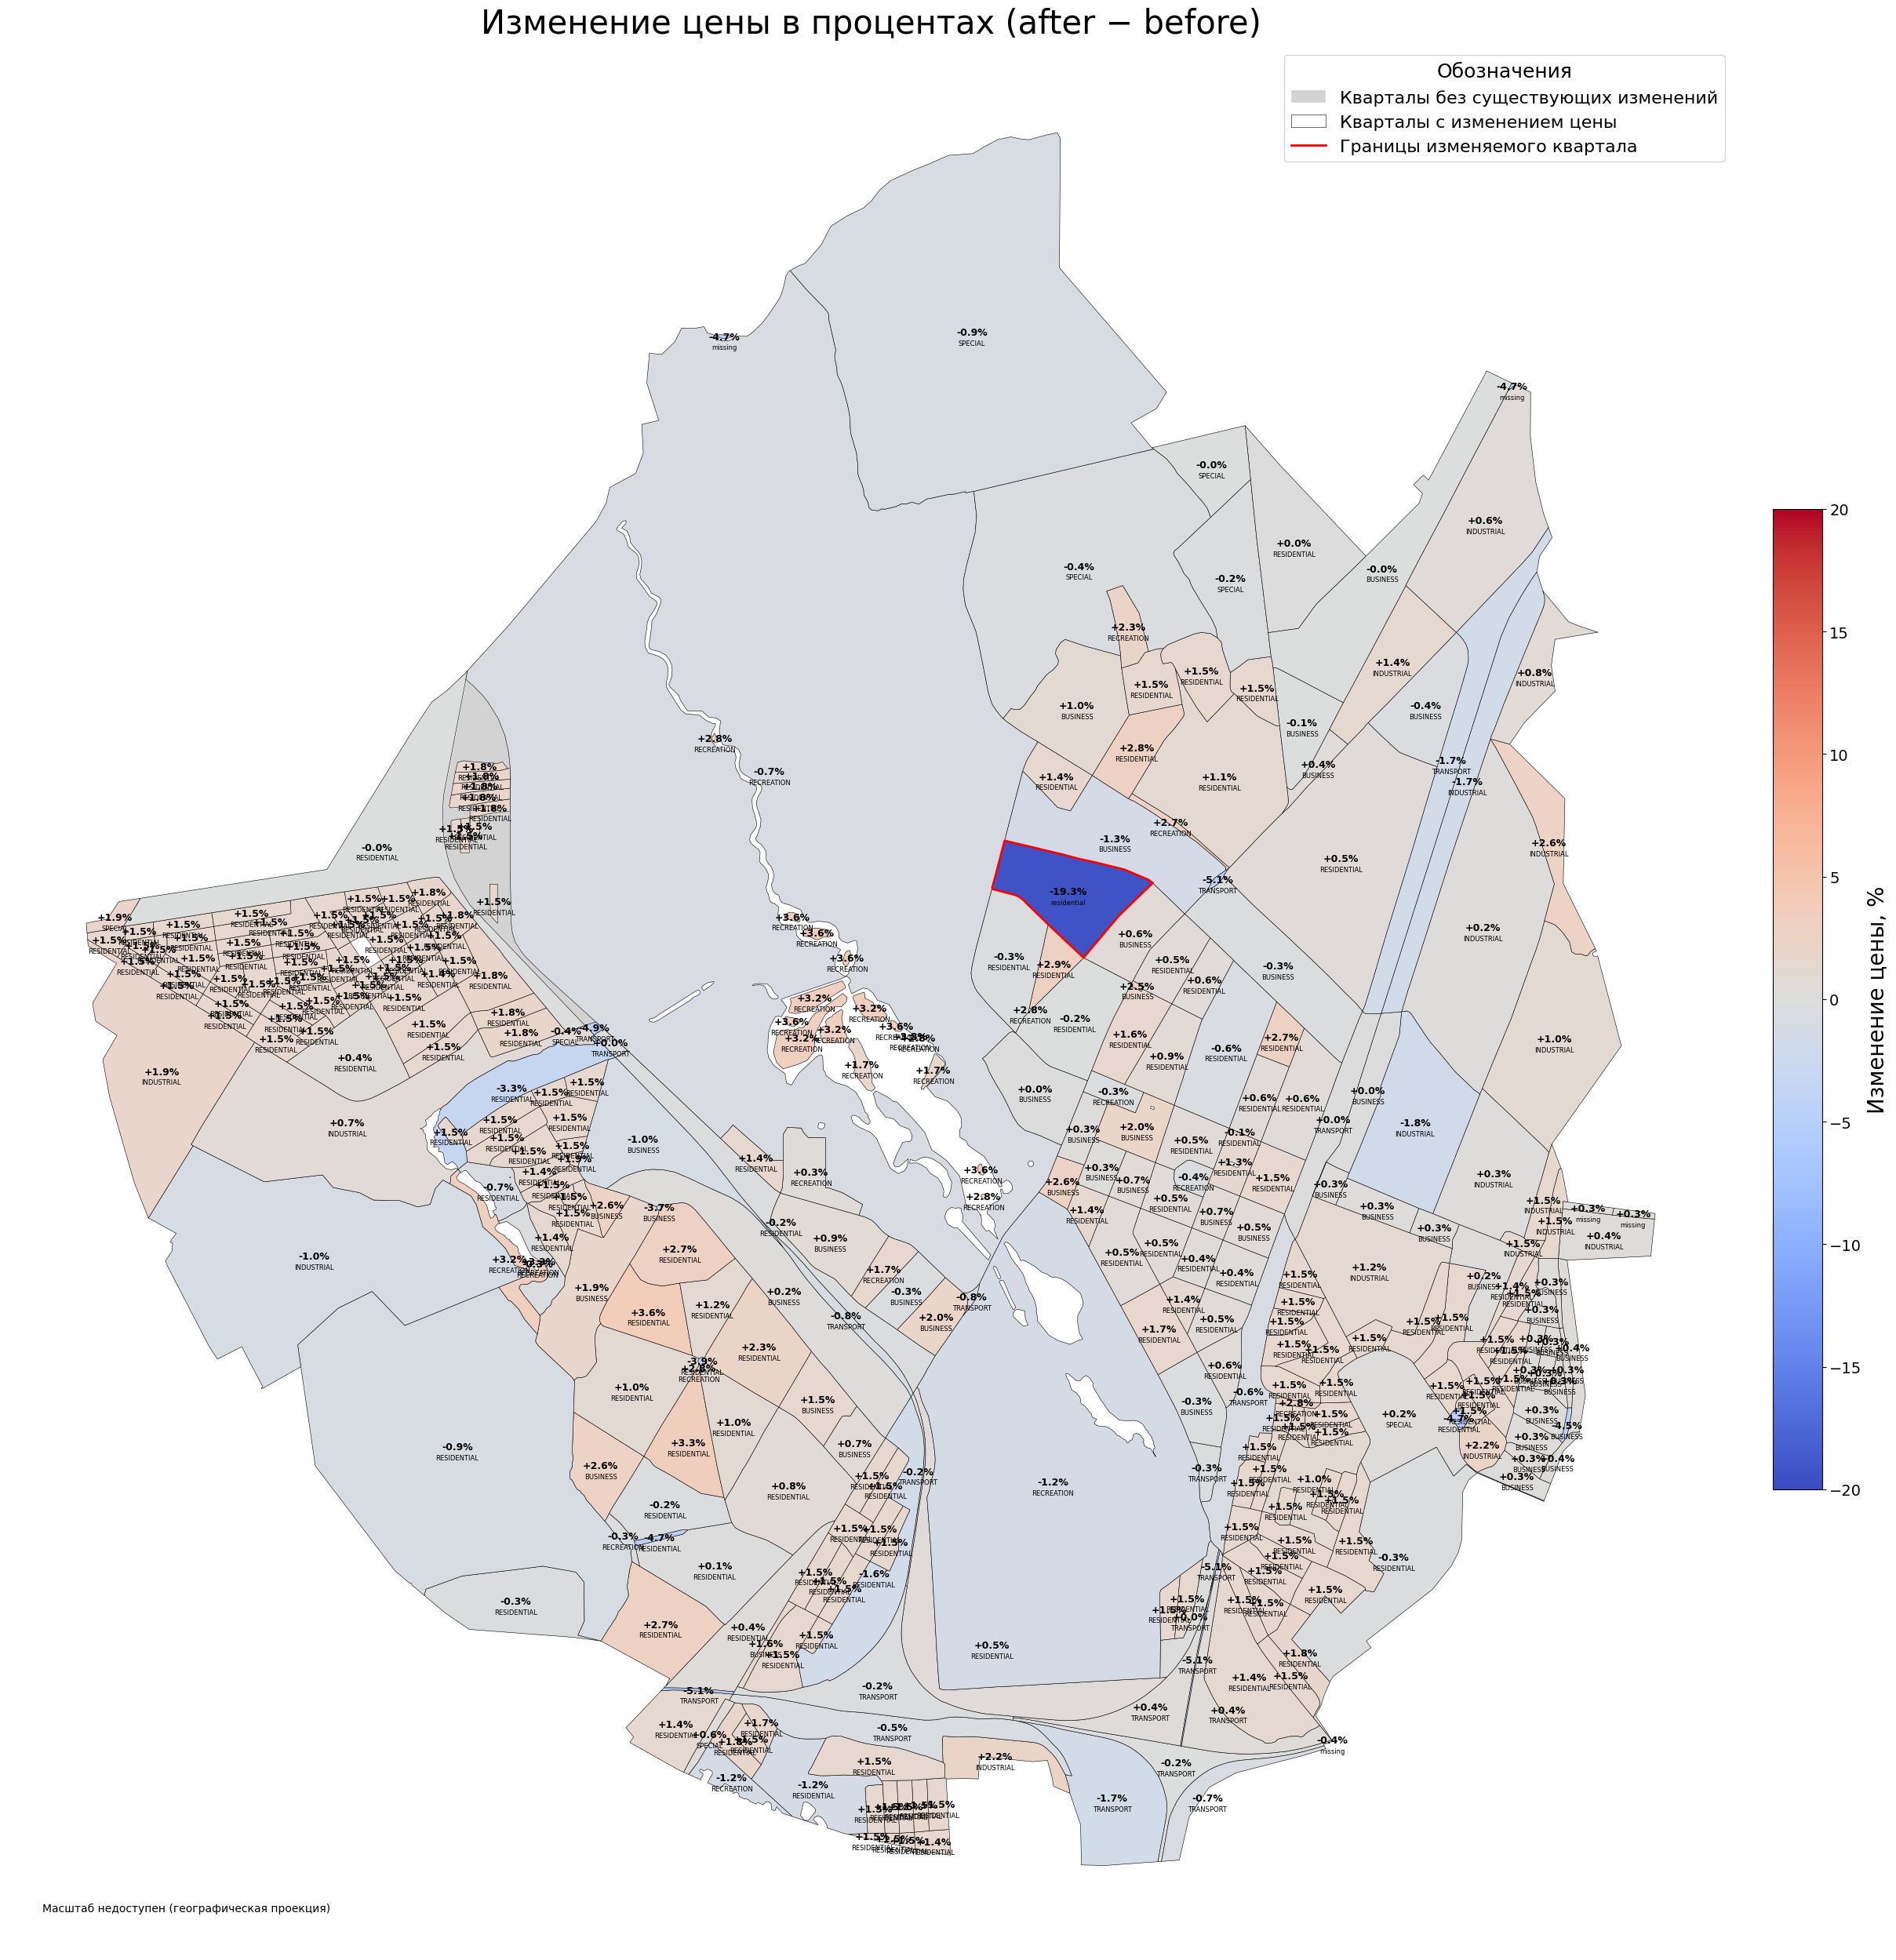


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | residential | 1 044 985 582 ₽ → 843 488 680 ₽ | -201 496 902 ₽ | -19.3%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 558 068 634 ₽ → 565 952 460 ₽ | +7 883 826 ₽ | +1.4%
248 | TRANSPORT | 463 610 653 ₽ → 455 740 498 ₽ | -7 870 155 ₽ | -1.7%
298 | TRANSPORT | 90 038 010 ₽ → 89 902 290 ₽ | -135 720 ₽ | -0.2%
115 | RESIDENTIAL | 129 175 469 ₽ → 131 105 737 ₽ | +1 930 268 ₽ | +1.5%
317 | RESIDENTIAL | 157 610 237 ₽ → 159 965 405 ₽ | +2 355 168 ₽ | +1.5%
318 | INDUSTRIAL | 283 475 839 ₽ → 289 767 143 ₽ | +6 291 304 ₽ | +2.2%
225 | TRANSPORT | 237 712 832 ₽ → 238 674 326 ₽ | +961 494 ₽ | +0.4%
299 | TRANSPORT | 3 887 664 ₽ → 3 690 731 ₽ | -196 933 ₽ | -5.1%
5 | TRANSPORT | 134 459 896 ₽ → 134 485 874 ₽ | +25 978 ₽ | +0.0%
113 | RESIDENTIAL | 14

{'map':      residential  business  recreation  industrial  transport   special  \
 311     0.957390  0.000000    0.000000    0.000000   0.000000  0.000000   
 248     0.000000  0.000000    0.000000    0.063868   0.741221  0.000000   
 298     0.000000  0.000000    0.000000    0.000000   0.999329  0.000000   
 115     0.955669  0.000000    0.044331    0.000000   0.000000  0.000000   
 317     0.858357  0.000000    0.068465    0.000000   0.000000  0.000000   
 ..           ...       ...         ...         ...        ...       ...   
 290     0.742723  0.003805    0.014400    0.000177   0.000000  0.238896   
 288     0.035634  0.000000    0.946904    0.000000   0.000000  0.017463   
 247     0.015964  0.000000    0.062648    0.015946   0.047933  0.857510   
 345     0.000000  0.000000    0.000000    0.000000   0.173390  0.825889   
 285     0.000000  0.000000    0.000000    0.000000   0.007811  0.953935   
 
      agriculture             land_use     share  footprint_area  ...  \
 311  

In [83]:
plot_scenario_impact(
    blocks_before=blocks_after,
    blocks_after=modifier.apply(target_idx, params_repaired),
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

In [84]:
import pandas as pd

blocks_gen = modifier.apply(target_idx, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,mxi,l,morphotype,area_accessibility,geometry,land_value,price_per_sotka,id,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08,81712.868330,0,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08,207723.484640,1,NaN,NaN
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08,202047.687390,2,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08,145310.813724,3,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08,143003.845248,4,NaN,NaN


In [85]:
gen_blocks.iloc[86]

residential                                                     0.28955
business                                                       0.090052
recreation                                                     0.092204
industrial                                                     0.140339
transport                                                      0.271406
special                                                        0.116431
agriculture                                                    0.000018
land_use                                            LandUse.RESIDENTIAL
share                                                           0.28955
footprint_area                                             50220.531057
build_floor_area                                           228844.57935
living_area                                                79907.156391
non_living_area                                           148937.422959
population                                                   399

In [86]:
blocks_after.iloc[86]

residential                                                    0.690324
business                                                       0.219805
recreation                                                     0.089872
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                          0.690324
footprint_area                                             33119.603537
build_floor_area                                          190588.496682
living_area                                               132192.815395
non_living_area                                            58395.681287
population                                                      

In [87]:
gen_blocks = gen_blocks.copy()
gen_blocks["is_project"] = False

# target_idx — индекс изменяемого квартала
if target_idx in gen_blocks.index:
    gen_blocks.loc[target_idx, "is_project"] = True
else:
    raise KeyError(f"target_idx={target_idx} не найден в gen_blocks.index")

investment_input = prepare_investment_input(
    gdf=gen_blocks,
    project_potential=potential_df,
)

summary = an.calculate_investment_metrics(
    investment_input,
    discount_rate=0.18,
    show_project_totals=True
)
summary

2026-02-18 14:59:58.067 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Project totals:
 • Land area:          705,080.04
 • Built area:         228,844.58
 • Land value:         1,066,618,958.46
 • Demolition cost:    205,960,121.41
 • Construction cost:  10,298,006,070.74
 • Investment need:    11,570,585,150.61
 • Spatial potential:  0.00
 • Project NPV:        5,246,841,035.51
 • Project IRR:        0.33
 • Project ROI:        5.43
 • Project PP (yrs):   5.31
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,228844.58,1.066619e+09,2.059601e+08,1.029801e+10,1.157059e+10,5.246841e+09,0.33,5.43,5.31,100.0,0.0,60.0


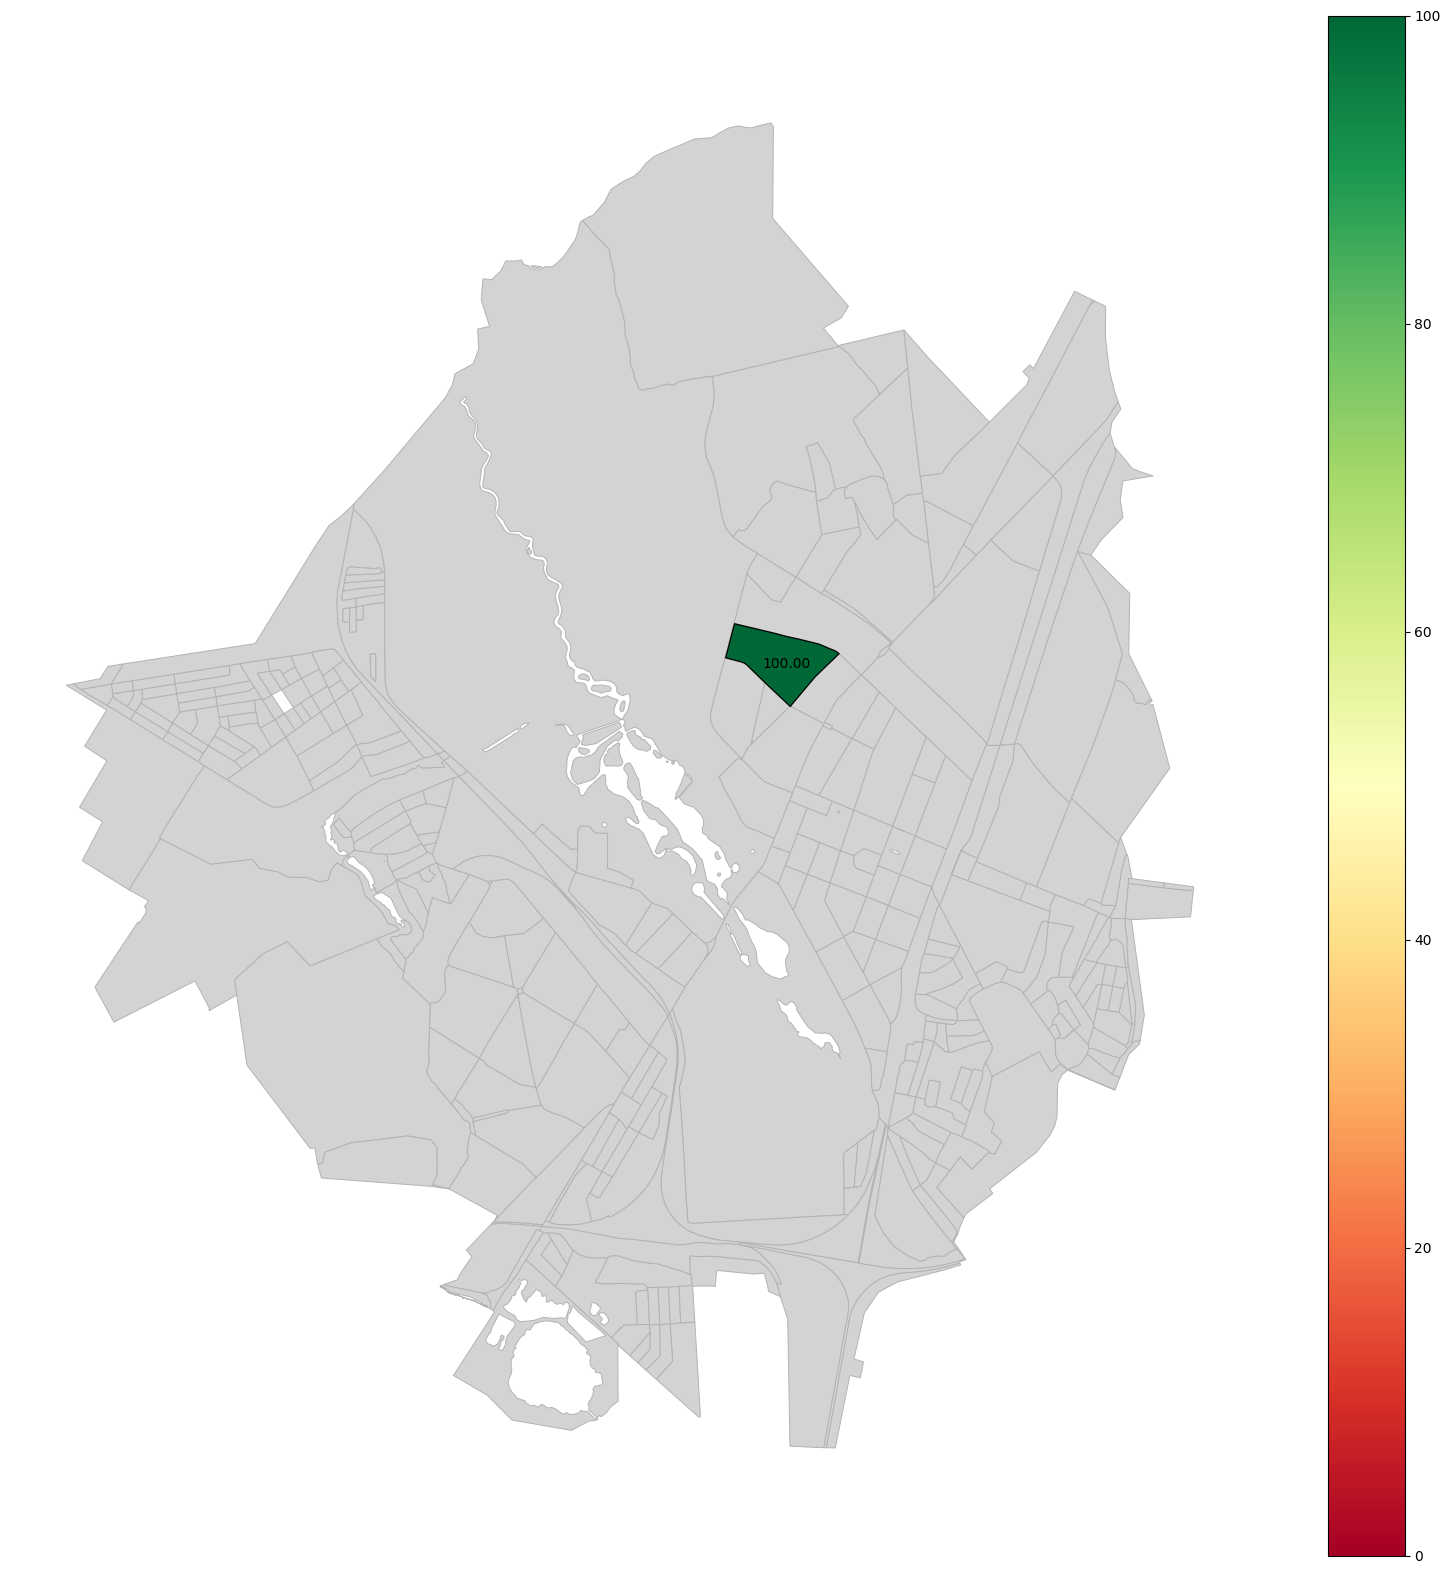

In [88]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [89]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,34 327
1,Валовый региональный продукт на душу населения,16 973
2,Доходы бюджета территории,617 880 364
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),293 493
